In [317]:
#imports
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve.utils import KeplerQualityFlags
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import InterpolationWarning

In [318]:
# This selects: one star: KIC 11904151; one observing quarter: quarter 5; Kepler pipeline data; long cadence, 
# roughly one observation every 29.4 minutes. The purpose of using one target and one quarter is to build and 
# understand the method before scaling it. Each row is one telescope observation.
search = lk.search_lightcurve("KIC 11904151", mission="Kepler", quarter=5, author="Kepler", cadence="long")
lc = search.download(quality_bitmask="none")
lc.head(3)

time,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,sap_quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,,d,pix,pix,,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,int32,float32,float64,float64,int32,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
443.4907927085369,———,———,10000,-3.622115e-04,659.35739,250.23768,16373,5.2833062e+05,1.9822861e+01,2.6258533e+03,1.1584756e+00,———,———,10000,———,———,———,———,659.35739,3.4764875e-05,250.23768,5.2465508e-05,2.6925206e-02,-5.7737276e-02
443.51122690278135,5.5163106e+05,2.0662918e+01,10000,-3.617172e-04,659.35710,250.23750,16374,5.2832656e+05,1.9822729e+01,2.6248147e+03,1.1592327e+00,5.5163106e+05,2.0662918e+01,10000,———,———,———,———,659.35710,3.4763889e-05,250.23750,5.2467920e-05,2.6598439e-02,-5.7927754e-02
443.5316608971698,5.5166250e+05,2.0671402e+01,10000,-3.612228e-04,659.35727,250.23762,16375,5.2837700e+05,1.9823277e+01,2.6280718e+03,1.1568583e+00,5.5166250e+05,2.0671402e+01,10000,———,———,———,———,659.35727,3.4761691e-05,250.23762,5.2459982e-05,2.6823662e-02,-5.7847586e-02


In [319]:
# The difference between consecutive time values corresponds to the cadence: 443.511227−443.490793≈0.020434 days
# Convert days to minutes: 0.020434×24×60≈29.4 minutes
# Kepler’s TIME column represents the barycentrically corrected midpoint of each cadence
df = pd.DataFrame({
    "time": np.asarray(lc.time.value, dtype=np.float64),
    "flux": np.asarray(lc.pdcsap_flux.value, dtype=np.float64),
    "flux_error": np.asarray(lc.pdcsap_flux_err.value, dtype=np.float64),
    "quality": np.asarray(lc.quality.value, dtype=np.int64),
    "cadenceno": np.asarray(lc.cadenceno.value, dtype=np.int64)}) # sequential identifier assigned to each Kepler exposure.
df.head()

,time,flux,flux_error,quality,cadenceno
0,443.490793,NaN,NaN,16,16373
1,443.511227,551631.0625,20.662918,16,16374
2,443.531661,551662.5000,20.671402,16,16375
3,443.552095,551695.3750,20.665833,16,16376
4,443.572529,551692.2500,20.662884,16,16377


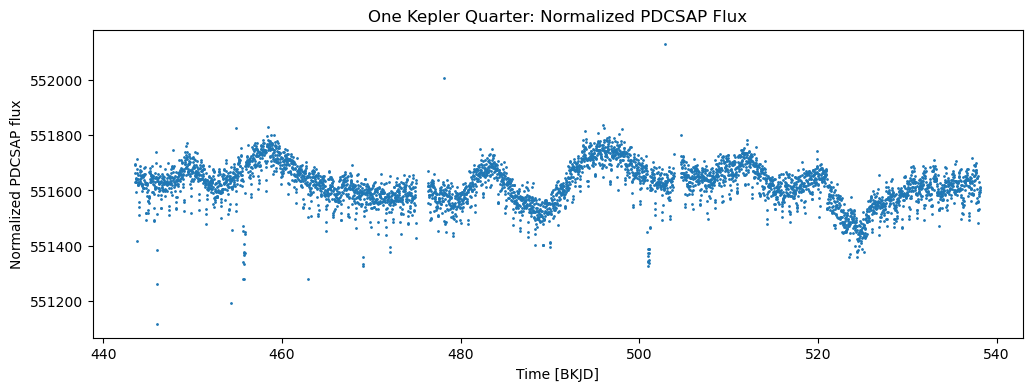

In [321]:
# The smooth waves indicate that observations are temporally related. 
# That is the structure ARIMA is intended to model.
plt.figure(figsize=(12, 4))
plt.plot(df["time"], df["flux"], ".", markersize=2)
plt.xlabel("Time [BKJD]")
plt.ylabel("Normalized PDCSAP flux")
plt.title("One Kepler Quarter: Normalized PDCSAP Flux")
plt.show()

In [322]:
# The > means big-endian, inherited from the FITS file.
print(df["flux"].dtype)
print(df["time"].dtype)
print(df["flux_error"].dtype)
print(df["quality"].dtype)

float64
float64
float64
int64


In [323]:
# Lightkurve’s Kepler default mask rejects flags such as: attitude tweak; safe mode; coarse pointing; Earth pointing; 
# desaturation event; manual exclusion; detector anomaly; no data; thruster firing. It does not reject every possible 
# nonzero quality flag. Lightkurve’s default mask treats the Kepler flag 16 as potentially usable, because it is 
# not included among the default rejection flags.
default_quality_mask = KeplerQualityFlags.create_quality_mask(quality_array=df["quality"].to_numpy(),bitmask="default")
df["passes_default_quality"] = default_quality_mask

# Decode every quality flag attached to each cadence.
def decode_quality_reason(quality_value):
    reasons = KeplerQualityFlags.decode(int(quality_value))
    if len(reasons) == 0:
        return "No quality flag"
    return "; ".join(reasons)
    
df["quality_reason"] = df["quality"].apply(decode_quality_reason)

In [324]:
def determine_exclusion_reason(row):
    reasons = []
    if not np.isfinite(row["time"]):
        reasons.append("Missing or invalid time")
    if not np.isfinite(row["flux"]):
        reasons.append("Missing or invalid flux")
    if not np.isfinite(row["flux_error"]):
        reasons.append("Missing or invalid flux error")
    if not row["passes_default_quality"]:
        # Decode only the flags that triggered the default rejection.
        rejected_bits = (int(row["quality"])& KeplerQualityFlags.DEFAULT_BITMASK)
        rejected_reasons = KeplerQualityFlags.decode(rejected_bits)
        if rejected_reasons:
            reasons.append("Rejected quality flag: " + "; ".join(rejected_reasons))
        else:
            reasons.append("Rejected by default quality mask")
    if not reasons:
        return "Usable"
    return "; ".join(reasons)
    
df["exclusion_reason"] = df.apply(determine_exclusion_reason,axis=1)
df["usable"] = df["exclusion_reason"].eq("Usable")
df["flux_for_model"] = df["flux"].where(df["usable"],np.nan)
df[["cadenceno","flux","flux_for_model","quality","passes_default_quality","usable","quality_reason","exclusion_reason"]].head(12)

,cadenceno,flux,flux_for_model,quality,passes_default_quality,usable,quality_reason,exclusion_reason
0,16373,NaN,NaN,16,True,False,Zero crossing,Missing or invalid flux; Missing or invalid fl...
1,16374,551631.0625,551631.0625,16,True,True,Zero crossing,Usable
2,16375,551662.5000,551662.5000,16,True,True,Zero crossing,Usable
3,16376,551695.3750,551695.3750,16,True,True,Zero crossing,Usable
4,16377,551692.2500,551692.2500,16,True,True,Zero crossing,Usable
5,16378,551631.9375,551631.9375,16,True,True,Zero crossing,Usable
6,16379,551632.0625,551632.0625,16,True,True,Zero crossing,Usable
7,16380,551644.1250,551644.1250,16,True,True,Zero crossing,Usable
8,16381,551641.2500,551641.2500,16,True,True,Zero crossing,Usable
9,16382,551641.7500,551641.7500,16,True,True,Zero crossing,Usable


In [325]:
# Sort by cadence number and verify that each cadence appears only once.
df = (df.sort_values("cadenceno").drop_duplicates(subset="cadenceno").reset_index(drop=True))

# Mark rows that were present in the original downloaded light curve.
df["row_present"] = True

# Construct every expected cadence number between the first and last cadence.
expected_cadences = np.arange(df["cadenceno"].min(), df["cadenceno"].max() + 1, dtype=np.int64)

# Reindex onto the complete cadence grid.
# Missing cadence numbers will become newly inserted rows containing NaNs.
regular_data = (df.set_index("cadenceno").reindex(expected_cadences).rename_axis("cadenceno").reset_index())

# Newly inserted cadence rows were not present in the original file.
# NaN values created by reindexing are treated as False.
# Using .eq(True) avoids Pandas' object-downcasting FutureWarning.
regular_data["row_present"] = regular_data["row_present"].eq(True)

# Newly inserted rows cannot be usable observations.
regular_data["usable"] = regular_data["usable"].eq(True)

regular_data["passes_default_quality"] = (regular_data["passes_default_quality"].eq(True))

#Reason for entirely absent rows
regular_data["gap_reason"] = np.where(~regular_data["row_present"],"Cadence absent from downloaded file",
                                        regular_data["exclusion_reason"].fillna("Observed but unusable"))
regular_data["is_gap"] = ~regular_data["usable"]

print("Rows originally present:", len(df))
print("Expected cadence positions:", len(regular_data))
print("Cadences absent from file:", (~regular_data["row_present"]).sum())
print("Observed but unusable:", (regular_data["row_present"] & ~regular_data["usable"]).sum())
print("Usable observations:", regular_data["usable"].sum())
print("Total gap positions:", regular_data["is_gap"].sum())
regular_data.loc[regular_data["is_gap"],["cadenceno","row_present","time","flux","quality","quality_reason","passes_default_quality","usable","gap_reason"]].head()

Rows originally present: 4538
Expected cadence positions: 4634
Cadences absent from file: 96
Observed but unusable: 52
Usable observations: 4486
Total gap positions: 148


,cadenceno,row_present,time,flux,quality,quality_reason,passes_default_quality,usable,gap_reason
0,16373,True,443.490793,NaN,16.0,Zero crossing,True,False,Missing or invalid flux; Missing or invalid fl...
36,16409,True,444.226420,NaN,16384.0,Detector anomaly,False,False,Missing or invalid flux; Missing or invalid fl...
57,16430,True,444.655536,NaN,4160.0,Argabrightening; Argabrightening on CCD,True,False,Missing or invalid flux; Missing or invalid fl...
71,16444,True,444.941614,NaN,32800.0,Desaturation event; No fine point,False,False,Missing or invalid flux; Missing or invalid fl...
218,16591,True,447.945428,NaN,32800.0,Desaturation event; No fine point,False,False,Missing or invalid flux; Missing or invalid fl...


In [329]:
# Inspect all rows present in the downloaded file but unusable for modelling.
observed_but_unusable = regular_data.loc[regular_data["row_present"] & ~regular_data["usable"],
    ["cadenceno","time","flux","flux_error","quality","quality_reason","passes_default_quality","gap_reason"]]
observed_but_unusable

,cadenceno,time,flux,flux_error,quality,quality_reason,passes_default_quality,gap_reason
0,16373,443.490793,NaN,NaN,16.0,Zero crossing,True,Missing or invalid flux; Missing or invalid fl...
36,16409,444.226420,NaN,NaN,16384.0,Detector anomaly,False,Missing or invalid flux; Missing or invalid fl...
57,16430,444.655536,NaN,NaN,4160.0,Argabrightening; Argabrightening on CCD,True,Missing or invalid flux; Missing or invalid fl...
71,16444,444.941614,NaN,NaN,32800.0,Desaturation event; No fine point,False,Missing or invalid flux; Missing or invalid fl...
218,16591,447.945428,NaN,NaN,32800.0,Desaturation event; No fine point,False,Missing or invalid flux; Missing or invalid fl...
317,16690,449.968407,NaN,NaN,16384.0,Detector anomaly,False,Missing or invalid flux; Missing or invalid fl...
363,16736,450.908377,NaN,NaN,32800.0,Desaturation event; No fine point,False,Missing or invalid flux; Missing or invalid fl...
509,16882,453.891762,NaN,NaN,32800.0,Desaturation event; No fine point,False,Missing or invalid flux; Missing or invalid fl...
656,17029,456.895584,NaN,NaN,32800.0,Desaturation event; No fine point,False,Missing or invalid flux; Missing or invalid fl...
801,17174,459.858539,NaN,NaN,32800.0,Desaturation event; No fine point,False,Missing or invalid flux; Missing or invalid fl...


In [331]:
# Identify the beginning of each uninterrupted usable segment.
segment_start = (regular_data["usable"] & ~regular_data["usable"].shift(fill_value=False))
regular_data["segment_id"] = (segment_start.cumsum().where(regular_data["usable"]))
observed_data = (regular_data.loc[regular_data["usable"]].copy())
segment_summary = (observed_data.groupby("segment_id").agg(observations=("cadenceno", "size"),
        start_cadence=("cadenceno", "min"), end_cadence=("cadenceno", "max"), start_time=("time", "min"), end_time=("time", "max")))
segment_summary["duration_days"] = (segment_summary["end_time"] - segment_summary["start_time"])
segment_summary = segment_summary.sort_values("observations",ascending=False)
longest_segment_id = segment_summary.index[0]
analysis_data = (observed_data.loc[observed_data["segment_id"] == longest_segment_id].copy().reset_index(drop=True))
cadence_steps = analysis_data["cadenceno"].diff().dropna()

print(display(segment_summary.head(10)))
print("Continuous observations:", len(analysis_data))
print("Continuous duration:",analysis_data["time"].iloc[-1] - analysis_data["time"].iloc[0], "days")
print("All cadence steps equal 1:", cadence_steps.eq(1).all())
print("Contains missing modelling flux:",analysis_data["flux_for_model"].isna().any())

,observations,start_cadence,end_cadence,start_time,end_time,duration_days
segment_id,,,,,,
19.0,146,17759,17904,471.812546,474.775507,2.962962
4.0,146,16445,16590,444.962048,447.924994,2.962946
8.0,146,16883,17028,453.912197,456.875150,2.962953
32.0,145,18931,19075,495.761451,498.703977,2.942526
46.0,145,20204,20348,521.774147,524.716657,2.942510
33.0,145,19077,19221,498.744846,501.687371,2.942525
24.0,145,18201,18345,480.844469,483.786997,2.942529
25.0,145,18347,18491,483.827866,486.770394,2.942529
47.0,145,20350,20494,524.757525,527.700032,2.942507


None
Continuous observations: 146
Continuous duration: 2.962961707460636 days
All cadence steps equal 1: True
Contains missing modelling flux: False


In [332]:
# split the raw flux first and calculate the normalization later using only the training set
segment_flux = analysis_data["flux"].to_numpy(dtype=np.float64)

initial_train_size = int(len(segment_flux) * 0.80)
train_flux_raw = segment_flux[:initial_train_size]
test_flux_raw = segment_flux[initial_train_size:]

# Estimate preprocessing only from training observations.
training_median_flux = np.median(train_flux_raw)

train = (train_flux_raw / training_median_flux - 1) * 1_000_000
test = (test_flux_raw / training_median_flux - 1) * 1_000_000

print("Training observations supplied to diagnostics:", len(train))
print("Train contains non-finite values:", ~np.isfinite(train).all())
print("Test observations supplied to diagnostics:", len(test))
print("Test contains non-finite values:", ~np.isfinite(test).all())

Training observations supplied to diagnostics: 116
Train contains non-finite values: False
Test observations supplied to diagnostics: 30
Test contains non-finite values: False


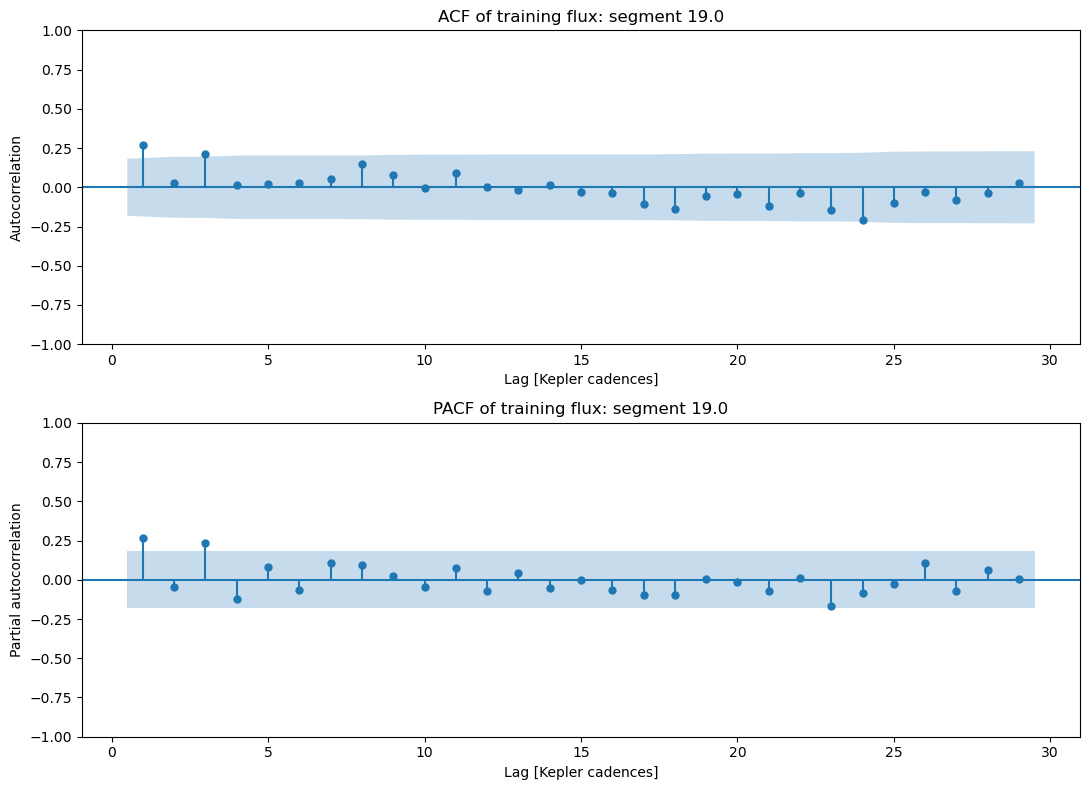

In [334]:
# ACF: total correlation between the current flux and each previous lag.
# PACF: direct correlation with a lag after controlling for shorter lags.
# The training set contains 116 consecutive observations.
# Because no cadence gap occurs within the selected segment,
# lag k corresponds to exactly k Kepler long-cadence intervals.

max_lag = min(40, len(train) // 4) # 29 lags
fig, axes = plt.subplots(2, 1, figsize=(11, 8))

plot_acf(train,lags=max_lag, zero=False, ax=axes[0])
axes[0].set_title(f"ACF of training flux: segment {longest_segment_id}")
axes[0].set_xlabel("Lag [Kepler cadences]")
axes[0].set_ylabel("Autocorrelation")

plot_pacf(train,lags=max_lag, zero=False, method="ywm", ax=axes[1])
axes[1].set_title(f"PACF of training flux: segment {longest_segment_id}")
axes[1].set_xlabel("Lag [Kepler cadences]")
axes[1].set_ylabel("Partial autocorrelation")
plt.tight_layout()
plt.show()

AUTOCORRELATION FUNCTION (ACF)



The ACF at lag k is: rho(k) = Corr(y_t, y_{t-k})
It asks: If the flux is high or low at one observation, does it also tend to be high or low k observations away?

INTERPRETING THE ACF
1. Large positive lag-1 ACF
High flux now -> the next flux value is likely to be high.
Low flux now  -> the next flux value is likely to be low.
This indicates short-term persistence between neighbouring observations.

2. Slowly declining positive ACF
Correlation remains positive across many lags.
This may indicate long-memory behaviour, red noise, an unremoved trend, or strong, smoothly varying stellar or instrumental variability.

3. Negative ACF
High flux now -> flux tends to be lower after k observations.
Low flux now  -> flux tends to be higher after k observations.
This suggests alternating, mean-reverting, or oscillatory behaviour.

4. Repeated peaks
Peaks occurring at regularly spaced lags may indicate periodic or quasi-periodic behaviour in the light curve.

WHAT THE ACF DOES NOT TELL US
ACF does not show whether lag k has a direct relationship with the current flux value.
For example, lag 10 may appear correlated with the current value only because dependence is transmitted through lags 1 to 9.

The Partial Autocorrelation Function (PACF) helps isolate the relationship between y_t and y_{t-k} after controlling for the intermediate lags.
Statsmodels therefore provides separate ACF and PACF estimators for these related but different diagnostics.

IMPORTANT SAMPLING CAUTION
In a filtered dataframe, lag 5 means five retained rows, not necessarily five consecutive Kepler cadences.
If observations were removed because of NaNs, quality flags, or data gaps, adjacent dataframe rows may be separated by more than one cadence. Therefore, ACF and PACF should preferably be calculated on a continuous,regularly sampled light-curve segment.

In [337]:
def stationarity_report(series, name="series", alpha=0.05):
    """
    Run complementary ADF and KPSS stationarity tests.
    ADF:
        H0: The series has a unit root and is non-stationary.
        p < alpha supports stationarity.

    KPSS:
        H0: The series is stationary around a constant mean.
        p >= alpha supports stationarity.
    """

    values = np.asarray(series, dtype=np.float64)

    if values.ndim != 1:
        raise ValueError(f"{name!r} must be one-dimensional," f"but received shape {values.shape}.")

    if not np.isfinite(values).all():
        nonfinite_count = int((~np.isfinite(values)).sum())
        raise ValueError(f"{name!r} contains {nonfinite_count} non-finite values. "
            "Use a continuous finite segment rather than dropping ""missing values inside this function.")

    if len(values) < 20:
        raise ValueError(f"{name!r} contains only {len(values)} observations.")

    if np.isclose(np.var(values), 0.0):
        raise ValueError(f"{name!r} has approximately zero variance.")

    # ADF: unit-root null hypothesis.
    adf_result = adfuller(values, regression="c", autolag="AIC")

    # KPSS: stationarity null hypothesis.
    # Capture the lookup-table boundary warning instead of printing it.
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", InterpolationWarning)
        kpss_result = kpss(values, regression="c", nlags="auto")

    kpss_boundary_warning = any(issubclass(warning.category, InterpolationWarning) for warning in caught)

    adf_pvalue = float(adf_result[1])
    kpss_pvalue = float(kpss_result[1])

    adf_supports_stationarity = adf_pvalue < alpha
    kpss_supports_stationarity = kpss_pvalue >= alpha

    if (adf_supports_stationarity and kpss_supports_stationarity):
        conclusion = "Stationary"

    elif (not adf_supports_stationarity and not kpss_supports_stationarity):
        conclusion = "Non-stationary"

    elif (adf_supports_stationarity and not kpss_supports_stationarity):
        conclusion = ("Conflicting: ADF supports stationarity, but KPSS rejects it")

    else:
        conclusion = ("Inconclusive: ADF does not reject a unit root, but KPSS does not reject stationarity")

    kpss_pvalue_display = (f">= {kpss_pvalue:.2f}" if kpss_boundary_warning else f"{kpss_pvalue:.6g}")

    return pd.Series({
        "series": name,
        "observations": len(values),
        "ADF statistic": adf_result[0],
        "ADF p-value": adf_pvalue,
        "ADF lags used": adf_result[2],
        "ADF decision": (
            "Reject unit-root H0"
            if adf_supports_stationarity
            else "Fail to reject unit-root H0"),
        "KPSS statistic": kpss_result[0],
        "KPSS p-value": kpss_pvalue,
        "KPSS p-value interpretation": kpss_pvalue_display,
        "KPSS lags used": kpss_result[2],
        "KPSS decision": (
            "Fail to reject stationarity H0"
            if kpss_supports_stationarity
            else "Reject stationarity H0"),
        "combined conclusion": conclusion})

In [338]:
# Run stationarity diagnostics using training data only.
raw_report = stationarity_report(train, name="training normalized flux")

# First difference of the training series: Δy_t = y_t - y_{t-1}
# train contains 116 observations, so train_diff contains 115.
train_diff = np.diff(train)

diff_report = stationarity_report(train_diff, name="first-differenced training normalized flux")

stationarity_results = pd.DataFrame([raw_report, diff_report])

display_columns = ["series",
                    "observations",
                    "ADF statistic",
                    "ADF p-value",
                    "ADF lags used",
                    "ADF decision",
                    "KPSS statistic",
                    "KPSS p-value interpretation",
                    "KPSS lags used",
                    "KPSS decision",
                    "combined conclusion"]

stationarity_results[display_columns]

,series,observations,ADF statistic,ADF p-value,ADF lags used,ADF decision,KPSS statistic,KPSS p-value interpretation,KPSS lags used,KPSS decision,combined conclusion
0,training normalized flux,116,-4.435520,2.566923e-04,3,Reject unit-root H0,0.282925,>= 0.10,3,Fail to reject stationarity H0,Stationary
1,first-differenced training normalized flux,115,-6.828068,1.924974e-09,6,Reject unit-root H0,0.083652,>= 0.10,20,Fail to reject stationarity H0,Stationary


# Stationarity Test Interpretation

The stationarity analysis was performed using only the **training portion** of the selected continuous Kepler segment.
Training normalized flux:
    Observations:      116
    ADF statistic:     -4.435520
    ADF p-value:       2.566923e-04
    KPSS statistic:     0.282925
    KPSS p-value:      >= 0.10
    Conclusion:        Stationary

First-differenced training normalized flux:
    Observations:      115
    ADF statistic:     -6.828068
    ADF p-value:       1.924974e-09
    KPSS statistic:     0.083652
    KPSS p-value:      >= 0.10
    Conclusion:        Stationary

    The training normalized flux is already stationary. First differencing is not required, so d=0 should be used for the primary ARIMA candidate search.
    
The complete segment contains 146 observations, but only the first 116 observations were used for:

- normalization;
- ACF and PACF analysis;
- stationarity testing;
- ARIMA-order selection;
- model fitting and in-sample comparison.

The final 30 observations were kept separate as an untouched holdout set for walk-forward validation.

The Augmented Dickey–Fuller and KPSS tests have opposite null hypotheses, so their results should be interpreted together.

---

## Test hypotheses

### Augmented Dickey–Fuller test

- \(p_{\mathrm{ADF}}<0.05\): reject the unit-root null and support stationarity;
- \(p_{\mathrm{ADF}}\geq0.05\): fail to reject the unit-root null.

### KPSS test


- \(p_{\mathrm{KPSS}}\geq0.05\): fail to reject the stationarity null;
- \(p_{\mathrm{KPSS}}<0.05\): reject the stationarity null.

The displayed value:
is a lookup-table boundary. It means that the true p-value is at least \(0.10\), not necessarily exactly \(0.10\).



## ADF result

The ADF result is: {ADF statistic}=-4.435520
ADF}}=2.566923\times10^{-4}

the unit-root null hypothesis is rejected.
Therefore, the ADF test supports the conclusion that the normalized training flux is stationary.

The ADF regression used:
3 lagged-difference terms. These were selected automatically by the AIC-based lag-selection procedure.
The three ADF lags are used only to control residual autocorrelation inside the ADF regression. They do **not** imply that the final ARIMA autoregressive order is 3

---

## KPSS result

Because the KPSS p-value is greater than \(0.05\), the stationarity null hypothesis is not rejected.

Therefore, the KPSS test also supports the conclusion that the normalized training flux is stationary around a constant mean.

The KPSS procedure used:
3 truncation lags when estimating the long-run variance.

These KPSS lags are internal to the stationarity test and do not represent the ARIMA values \(p\) or \(q\).

---

## Combined conclusion for the training flux

The two tests agree:

```text
ADF  -> rejects the unit-root null
KPSS -> fails to reject the stationarity null

In [342]:
candidate_orders = [
    (0, 0, 0),
    (1, 0, 0),
    (0, 0, 1),
    (1, 0, 1),
    (2, 0, 0),
    (3, 0, 0),
    (0, 1, 0),
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1)]

fitted_models = {}
fit_rows = []

for order in candidate_orders:
    p, d, q = order

    try:
        # Estimate a constant only for stationary d=0 models.
        # For d=1 challengers, omit the constant because differencing
        # would eliminate a level constant.
        trend = "c" if d == 0 else "n"

        model = ARIMA(train, order=order,trend=trend, enforce_stationarity=True, enforce_invertibility=True)
        result = model.fit()
        fitted_models[order] = result
        fit_rows.append({"order": order,"trend": trend,
            "converged": bool(result.mle_retvals.get("converged", True)),
            "log_likelihood": result.llf,
            "AIC": result.aic,
            "BIC": result.bic,
            "HQIC": result.hqic,
            "parameters": result.params.size,
            "error": None})

    except Exception as exc:
        fit_rows.append({
            "order": order,
            "trend": trend,
            "converged": False,
            "log_likelihood": np.nan,
            "AIC": np.nan,
            "BIC": np.nan,
            "HQIC": np.nan,
            "parameters": np.nan,
            "error": str(exc)})

fit_comparison = (pd.DataFrame(fit_rows).sort_values(["BIC", "AIC"],na_position="last").reset_index(drop=True))
print("Candidate fitting observations:", len(train))
print("Holdout observations excluded:", len(test))
fit_comparison

Candidate fitting observations: 116
Holdout observations excluded: 30


,order,trend,converged,log_likelihood,AIC,BIC,HQIC,parameters,error
0,"(0, 1, 1)",n,True,-671.252824,1346.505649,1351.995513,1348.733957,2,None
1,"(1, 1, 1)",n,True,-669.250421,1344.500843,1352.735639,1347.843305,3,None
2,"(1, 0, 1)",c,True,-668.936585,1345.873169,1356.887530,1350.344371,4,None
3,"(0, 0, 1)",c,True,-671.559821,1349.119643,1357.380413,1352.473044,3,None
4,"(1, 0, 0)",c,True,-672.490432,1350.980865,1359.241635,1354.334265,3,None
5,"(3, 0, 0)",c,True,-669.080562,1348.161125,1361.929076,1353.750126,5,None
6,"(0, 0, 0)",c,True,-676.767328,1357.534656,1363.041837,1359.770257,2,None
7,"(2, 0, 0)",c,True,-672.358367,1352.716734,1363.731095,1357.187935,4,None
8,"(1, 1, 0)",n,True,-686.411741,1376.823481,1382.313346,1379.051790,2,None
9,"(0, 1, 0)",n,True,-693.351172,1388.702343,1391.447276,1389.816498,1,None


# Initial ARIMA Fit Comparison

All candidate models were fitted using only the **116 training observations**.

The final 30 observations were excluded from fitting and remain reserved for out-of-sample validation.

All ten candidate models converged successfully, and no fitting errors were reported.

The models were compared using:

- log likelihood;
- Akaike Information Criterion (AIC);
- Bayesian Information Criterion (BIC);
- Hannan–Quinn Information Criterion (HQIC).

Lower AIC, BIC, and HQIC values indicate a better trade-off between model fit and complexity.

---

## Current information-criterion leaders

The criteria do not select exactly the same model.

### Lowest AIC

The lowest AIC was obtained by:

$$
\operatorname{ARIMA}(1,1,1)
$$

with:

```text
AIC  = 1344.50
BIC  = 1352.74
HQIC = 1347.84

In [343]:
# Inspect the three current information-criterion finalists.
leading_orders = [
    (1, 1, 1),  # lowest AIC and HQIC
    (0, 1, 1),  # lowest BIC
    (1, 0, 1),  # strongest stationarity-supported d=0 model
]

parameter_tables = {}

for order in leading_orders:
    result = fitted_models[order]

    parameter_table = pd.DataFrame({
        "parameter": result.param_names,
        "estimate": result.params,
        "standard_error": result.bse,
        "z_statistic": result.params / result.bse,
        "p_value": result.pvalues,
        "significant_at_5pct": result.pvalues < 0.05 })

    parameter_tables[order] = parameter_table

    print("=" * 70)
    print(f"ARIMA{order} | "f"trend={result.model.trend!r} | "f"observations={result.nobs}")
    print("=" * 70)
    display(parameter_table)

ARIMA(1, 1, 1) | trend='n' | observations=116


,parameter,estimate,standard_error,z_statistic,p_value,significant_at_5pct
0,ar.L1,0.276171,0.083543,3.305754,9.472135e-04,True
1,ma.L1,-0.997519,0.146037,-6.830597,8.456224e-12,True
2,sigma2,6424.172171,1105.831540,5.809359,6.271256e-09,True


ARIMA(0, 1, 1) | trend='n' | observations=116


,parameter,estimate,standard_error,z_statistic,p_value,significant_at_5pct
0,ma.L1,-0.830730,0.055076,-15.083424,2.081869e-51,True
1,sigma2,6808.664228,524.346856,12.985039,1.487629e-38,True


ARIMA(1, 0, 1) | trend='c' | observations=116


,parameter,estimate,standard_error,z_statistic,p_value,significant_at_5pct
0,const,-6.265233,11.000102,-0.569561,5.689752e-01,False
1,ar.L1,-0.476787,0.173917,-2.741456,6.116762e-03,True
2,ma.L1,0.811843,0.120724,6.724761,1.758814e-11,True
3,sigma2,5956.968513,606.657252,9.819331,9.295816e-23,True


# Parameter Estimate Interpretation

The three information-criterion finalists were examined using their estimated
coefficients, standard errors, z-statistics, and p-values.

## ARIMA(1,1,1)

The estimated coefficients were:

\[
\phi_1=0.2762
\]

and:

\[
\theta_1=-0.9975
\]

Both coefficients were statistically significant at the 5% level.

However, the MA coefficient is extremely close to the invertibility boundary
at \(-1\).

Because the original training flux was already stationary, this boundary-like
MA estimate suggests that first differencing may have over-differenced the
series. The MA term may be compensating for the artificial negative
autocorrelation introduced by unnecessary differencing.

Therefore, ARIMA(1,1,1) should not be selected solely because it achieved the
lowest AIC.

## ARIMA(0,1,1)

The estimated MA coefficient was:

\[
\theta_1=-0.8307
\]

and was highly statistically significant.

Unlike the ARIMA(1,1,1) estimate, this coefficient is not extremely close to
\(-1\). ARIMA(0,1,1) therefore remains a credible differenced challenger.

Nevertheless, it uses \(d=1\) even though the training-only ADF and KPSS tests
support \(d=0\). It must therefore be compared with the stationary models
using residual diagnostics and out-of-sample validation.

## ARIMA(1,0,1)

The estimated constant was:

\[
c=-6.27
\]

with:

\[
p=0.569
\]

The constant is not statistically significant. This is consistent with the
normalization procedure, which centred the training flux near zero.

The AR and MA coefficients were:

\[
\phi_1=-0.4768
\]

and:

\[
\theta_1=0.8118
\]

Both were statistically significant.

Therefore, the ARMA structure appears meaningful, but the model should be
refitted without a constant.

## Current implication

ARIMA(1,1,1) shows a strong possible over-differencing warning because its MA
coefficient is approximately \(-1\).

ARIMA(0,1,1) remains the strongest differenced challenger.

ARIMA(1,0,1) remains the strongest stationarity-supported model, but it should
be refitted without a constant.

The significance of `sigma2` is not used to select the ARIMA order because it
represents the estimated innovation variance rather than an AR or MA lag.

In [344]:
refined_specs = [
    ((0, 1, 1), "n"),  # BIC-leading differenced challenger
    ((0, 0, 1), "n"),  # simpler stationary challenger
    ((1, 0, 1), "n"),  # leading stationary ARMA model
]

refined_models = {}
refined_rows = []

for order, trend in refined_specs:
    result = ARIMA(
        train,
        order=order,
        trend=trend,
        enforce_stationarity=True,
        enforce_invertibility=True
    ).fit()

    refined_models[(order, trend)] = result

    refined_rows.append({
        "order": order,
        "trend": trend,
        "observations": result.nobs,
        "converged": bool(
            result.mle_retvals.get("converged", True)
        ),
        "log_likelihood": result.llf,
        "AIC": result.aic,
        "BIC": result.bic,
        "HQIC": result.hqic,
        "parameters": result.params.size
    })

refined_comparison = (
    pd.DataFrame(refined_rows)
    .sort_values(["BIC", "AIC"])
    .reset_index(drop=True)
)

refined_comparison

,order,trend,observations,converged,log_likelihood,AIC,BIC,HQIC,parameters
0,"(0, 1, 1)",n,116,True,-671.252824,1346.505649,1351.995513,1348.733957,2
1,"(1, 0, 1)",n,116,True,-669.187049,1344.374098,1352.634869,1347.727499,3
2,"(0, 0, 1)",n,116,True,-671.752288,1347.504576,1353.011756,1349.740177,2


These results make the competition much closer.

Interpretation
Model	AIC	BIC	HQIC
ARIMA(1,0,1), no constant	1344.37	1352.63	1347.73
ARIMA(0,1,1), no constant	1346.51	1352.00	1348.73
ARIMA(0,0,1), no constant	1347.50	1353.01	1349.74

The criteria disagree:

AIC and HQIC prefer ARIMA(1,0,1).
BIC prefers ARIMA(0,1,1).

However, the BIC difference is only:

1352.63−1352.00=0.64

That is very small, so BIC does not provide strong evidence against ARIMA(1,0,1).

The AIC difference is:

1346.51−1344.37=2.13

which gives moderate support to ARIMA(1,0,1), though it is not decisive.

Because the stationarity tests support d=0, the current provisional preference is:

ARIMA(1,0,1), trend="n"
	​


But ARIMA(0,1,1) must remain a challenger until residual and holdout diagnostics are compared.

In [345]:
for spec, result in refined_models.items():
    order, trend = spec

    parameter_table = pd.DataFrame({
        "parameter": result.param_names,
        "estimate": result.params,
        "standard_error": result.bse,
        "z_statistic": result.params / result.bse,
        "p_value": result.pvalues,
        "significant_at_5pct": result.pvalues < 0.05
    })

    print("=" * 70)
    print(
        f"ARIMA{order}, trend={trend!r}, "
        f"observations={int(result.nobs)}"
    )
    print("=" * 70)

    display(parameter_table)

ARIMA(0, 1, 1), trend='n', observations=116


,parameter,estimate,standard_error,z_statistic,p_value,significant_at_5pct
0,ma.L1,-0.830730,0.055076,-15.083424,2.081869e-51,True
1,sigma2,6808.664228,524.346856,12.985039,1.487629e-38,True


ARIMA(0, 0, 1), trend='n', observations=116


,parameter,estimate,standard_error,z_statistic,p_value,significant_at_5pct
0,ma.L1,0.360109,0.085619,4.205937,2.600024e-05,True
1,sigma2,6265.573200,409.755683,15.290998,8.779479e-53,True


ARIMA(1, 0, 1), trend='n', observations=116


,parameter,estimate,standard_error,z_statistic,p_value,significant_at_5pct
0,ar.L1,-0.472113,0.172784,-2.732383,6.287799e-03,True
1,ma.L1,0.810013,0.120591,6.717046,1.854458e-11,True
2,sigma2,5983.523202,522.314401,11.455788,2.199530e-30,True


ARIMA(0,1,1), no constant
θ
1
	​

=−0.8307,p≈0

The MA term is highly significant. However, the model applies first differencing even though the training-only ADF and KPSS tests support d=0.

It remains a valid challenger, but it must outperform the stationary models to justify differencing.

ARIMA(0,0,1), no constant
θ
1
	​

=0.3601,p=2.60×10
−5

The MA term is statistically significant. This is a simple stationary MA(1) model.

ARIMA(1,0,1), no constant
ϕ
1
	​

=−0.4721,p=0.0063
θ
1
	​

=0.8100,p=1.85×10
−11

Both the AR and MA terms are significant. The model therefore contains meaningful AR and MA structure after removing the unnecessary constant.

In [346]:
diagnostic_rows = []
ljung_box_tables = {}

for spec, result in refined_models.items():
    order, trend = spec
    p, d, q = order

    residuals = np.asarray(
        result.resid,
        dtype=np.float64
    )

    burn = int(
        getattr(result, "loglikelihood_burn", 0)
    )

    residuals = residuals[burn:]
    residuals = residuals[np.isfinite(residuals)]

    max_lag = min(20, len(residuals) // 4)

    residual_acf = acf(
        residuals,
        nlags=max_lag,
        fft=False
    )

    acf_without_zero = residual_acf[1:]

    largest_acf_lag = int(
        np.argmax(np.abs(acf_without_zero)) + 1
    )

    largest_acf_value = float(
        residual_acf[largest_acf_lag]
    )

    lags = [
        lag for lag in [5, 10, 20]
        if lag <= max_lag and lag > p + q
    ]

    lb_table = acorr_ljungbox(
        residuals,
        lags=lags,
        model_df=p + q,
        return_df=True
    )

    ljung_box_tables[spec] = lb_table

    diagnostic_rows.append({
        "order": order,
        "trend": trend,
        "AIC": result.aic,
        "BIC": result.bic,
        "residual_variance": np.var(
            residuals,
            ddof=1
        ),
        "largest_residual_ACF_lag": largest_acf_lag,
        "largest_residual_ACF_value": largest_acf_value,
        "minimum_Ljung_Box_p_value": (
            lb_table["lb_pvalue"].min()
        ),
        "residuals_approximately_white": (
            lb_table["lb_pvalue"].min() > 0.05
        )
    })

residual_diagnostics = (
    pd.DataFrame(diagnostic_rows)
    .sort_values(
        ["residuals_approximately_white", "BIC"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

residual_diagnostics

,order,trend,AIC,BIC,residual_variance,largest_residual_ACF_lag,largest_residual_ACF_value,minimum_Ljung_Box_p_value,residuals_approximately_white
0,"(0, 1, 1)",n,1346.505649,1351.995513,6875.864868,2,-0.142995,0.118207,True
1,"(1, 0, 1)",n,1344.374098,1352.634869,6012.329618,3,0.132844,0.323317,True
2,"(0, 0, 1)",n,1347.504576,1353.011756,6299.266487,3,0.240568,0.080139,True


All three models have:p Ljung–Box>0.05
so residual whiteness is not rejected for any finalist.

However, ARIMA(1,0,1) has:
the lowest AIC;
the lowest residual variance;
the highest minimum Ljung–Box p-value;
the smallest important residual ACF magnitude among the stationary models;
the stationarity-supported choice d=0.

Therefore, the current provisional leader is: ARIMA(1,0,1), trend="n"
ARIMA(0,1,1) still has the lowest BIC, but its advantage is only: 1352.63−1352.00=0.64
which is very small. It also uses unnecessary differencing and has substantially larger residual variance.

ARIMA(1,0,1) has:

the lowest AIC;
the lowest residual variance;
the largest minimum Ljung–Box p-value;
statistically significant AR and MA coefficients;
the stationarity-supported differencing order d=0.

ARIMA(0,1,1) has the lowest BIC, but its BIC advantage over ARIMA(1,0,1) is
only: 1352.63−1352.00=0.64

This difference is too small to constitute strong evidence in favour of the
differenced model.

ARIMA(0,1,1) also has the largest residual variance and uses first
differencing even though the original training series was already stationary.

Provisional conclusion

The current provisional leader is: ARIMA(1,0,1) fitted without a constant.

ARIMA(0,1,1) and ARIMA(0,0,1) remain challengers until the models are compared
on the untouched 30-observation holdout set.

The final model must be selected using walk-forward out-of-sample validation,
not from the training diagnostics alone.

In [349]:
finalist_specs = [
    ((1, 0, 1), "n"),
    ((0, 1, 1), "n"),
    ((0, 0, 1), "n"),
]

validation_rows = []
validation_predictions = {}

for order, trend in finalist_specs:
    history = list(train)

    predictions = []
    forecast_errors = []
    negative_log_scores = []

    for actual_value in test:
        result = ARIMA(
            np.asarray(history, dtype=np.float64),
            order=order,
            trend=trend,
            enforce_stationarity=True,
            enforce_invertibility=True
        ).fit()

        forecast = result.get_forecast(steps=1)

        predicted_value = float(
            np.asarray(forecast.predicted_mean).ravel()[0]
        )

        forecast_variance = float(
            np.asarray(forecast.var_pred_mean).ravel()[0]
        )

        forecast_variance = max(
            forecast_variance,
            np.finfo(float).eps
        )

        error = float(actual_value - predicted_value)

        predictions.append(predicted_value)
        forecast_errors.append(error)

        negative_log_scores.append(
            0.5 * (
                np.log(2 * np.pi * forecast_variance)
                + error**2 / forecast_variance
            )
        )

        history.append(float(actual_value))

    predictions = np.asarray(predictions, dtype=np.float64)
    forecast_errors = np.asarray(forecast_errors, dtype=np.float64)

    validation_predictions[(order, trend)] = predictions

    lb_table = acorr_ljungbox(
        forecast_errors,
        lags=[3, 5, 7, 10],
        model_df=0,
        return_df=True
    )

    validation_rows.append({
        "order": order,
        "trend": trend,
        "training_observations": len(train),
        "test_observations": len(test),
        "RMSE": np.sqrt(np.mean(forecast_errors**2)),
        "MAE": np.mean(np.abs(forecast_errors)),
        "mean_negative_log_score": np.mean(
            negative_log_scores
        ),
        "LB_p_lag_3": lb_table.loc[3, "lb_pvalue"],
        "LB_p_lag_5": lb_table.loc[5, "lb_pvalue"],
        "LB_p_lag_7": lb_table.loc[7, "lb_pvalue"],
        "LB_p_lag_10": lb_table.loc[10, "lb_pvalue"]
    })

validation_comparison = (
    pd.DataFrame(validation_rows)
    .sort_values(["RMSE", "MAE"])
    .reset_index(drop=True)
)

validation_comparison

,order,trend,training_observations,test_observations,RMSE,MAE,mean_negative_log_score,LB_p_lag_3,LB_p_lag_5,LB_p_lag_7,LB_p_lag_10
0,"(0, 0, 1)",n,116,30,57.919904,46.639113,5.547406,0.441327,0.043516,0.002819,0.000887
1,"(1, 0, 1)",n,116,30,62.287728,50.924987,5.586279,0.146104,0.003098,0.000206,0.000030
2,"(0, 1, 1)",n,116,30,72.700163,59.467521,5.718692,0.026202,0.001248,0.000013,0.000003


Current model-selection conclusion

The current segment-level winner is:

ARIMA(0,0,1)

fitted without a constant.

It is preferred because it:

respects the stationarity-supported choice d=0;
has the simplest dynamic structure among the competitive models;
has the lowest holdout RMSE;
has the lowest holdout MAE;
has the lowest mean negative log score;
substantially outperforms the differenced challenger.

However, it should not yet be treated as the final target-specific ARIMA
model because its forecast errors remain autocorrelated from approximately
lag 5 onward.

It should currently be described as the best single-segment ARIMA baseline.
The next stage is to test whether this result remains stable across multiple
validation origins and multiple continuous segments.

ARIMA(1, 0, 1), trend='n'


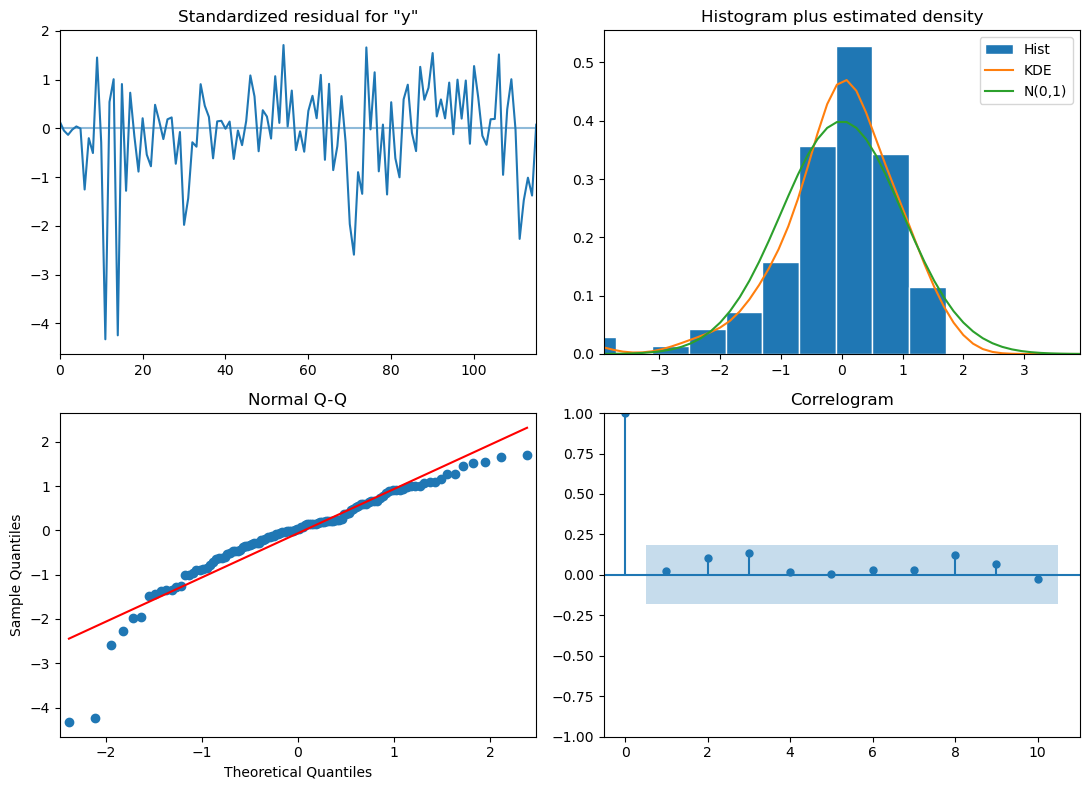

ARIMA(0, 1, 1), trend='n'


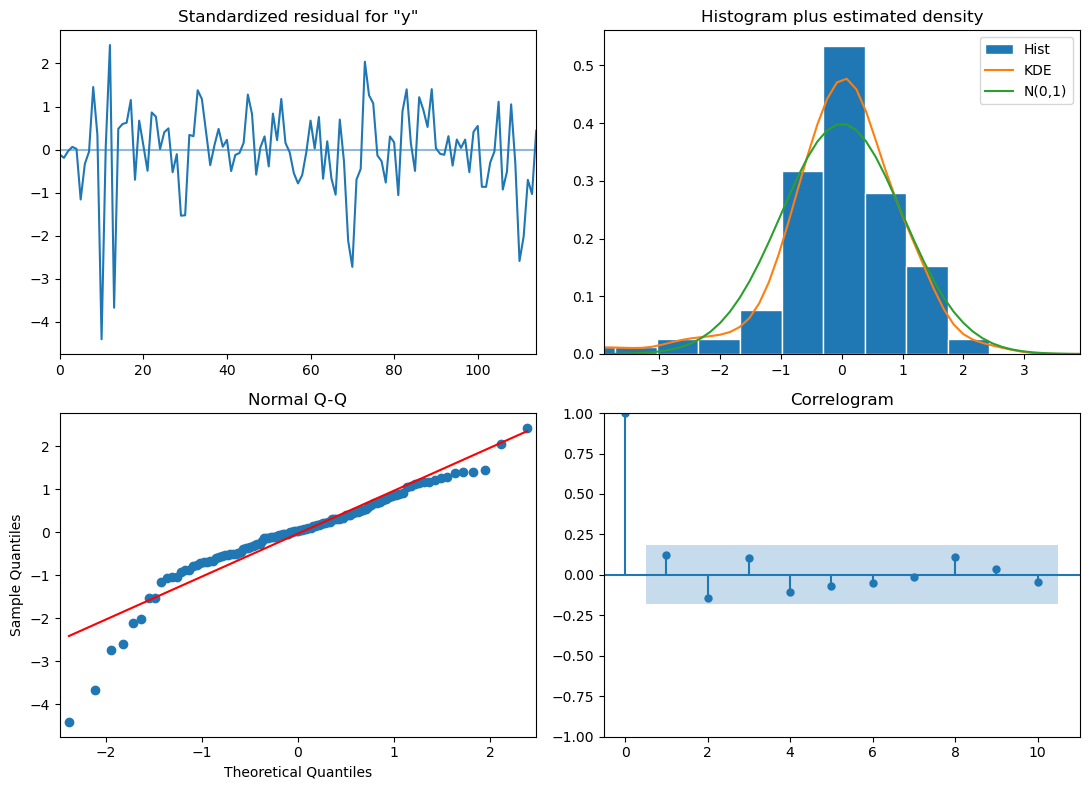

ARIMA(0, 0, 1), trend='n'


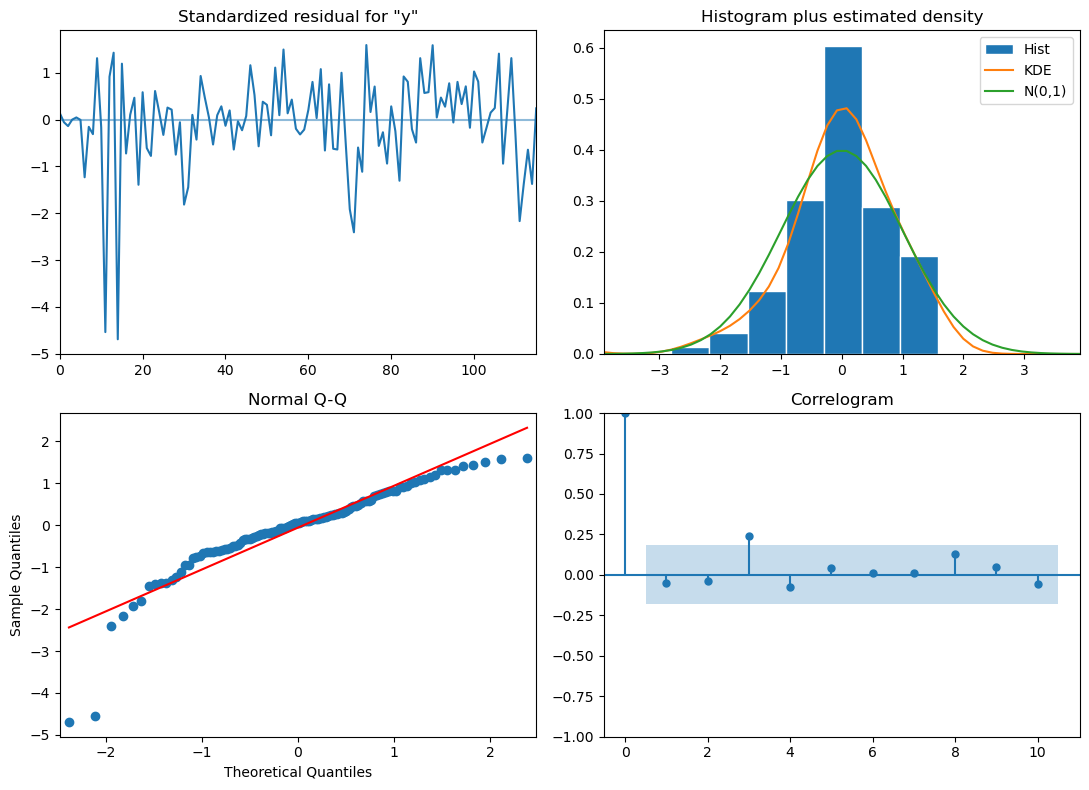

In [351]:
for order, trend in finalist_specs:
    result = refined_models[(order, trend)]

    print("=" * 80)
    print(f"ARIMA{order}, trend={trend!r}")
    print("=" * 80)

    result.plot_diagnostics(figsize=(11, 8))
    plt.tight_layout()
    plt.show()

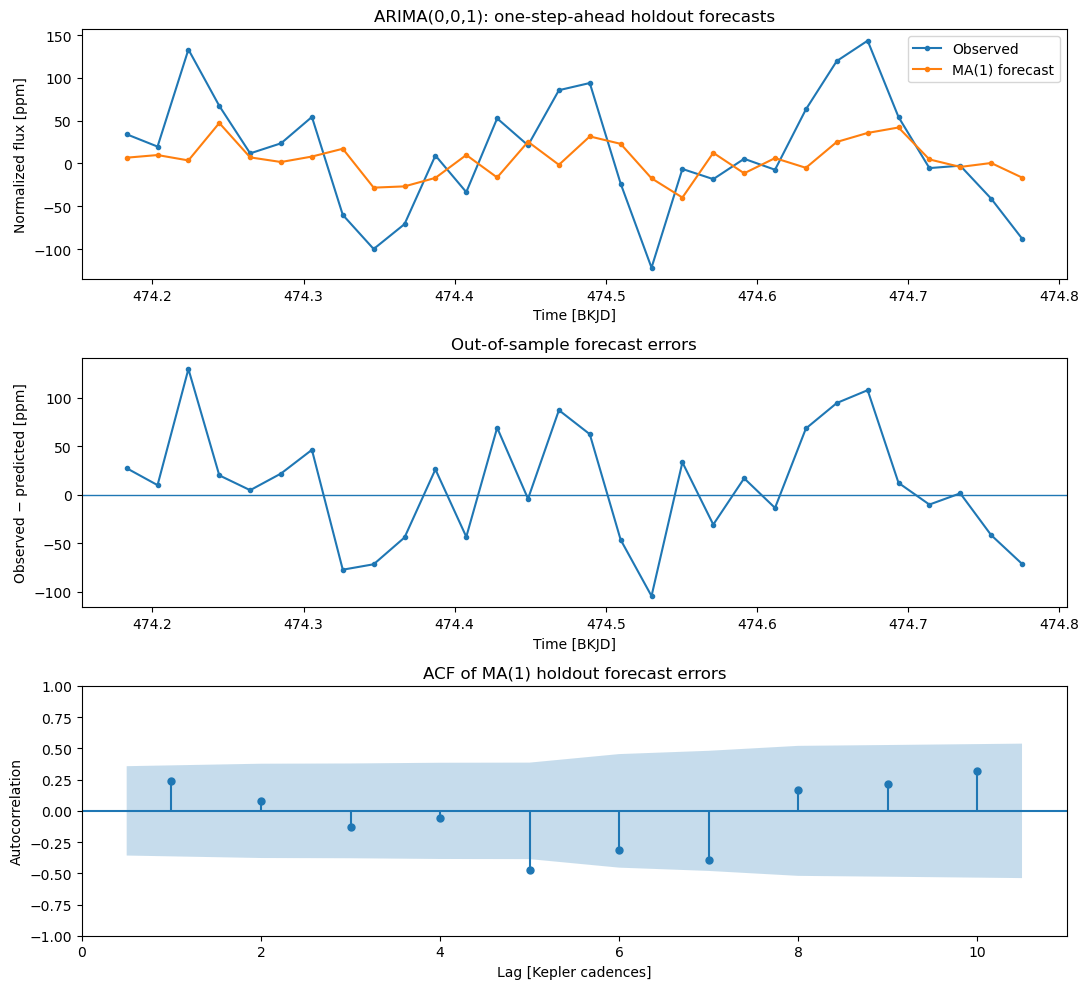

In [350]:
winning_spec = ((0, 0, 1), "n")

winning_predictions = np.asarray(
    validation_predictions[winning_spec],
    dtype=np.float64
)

test_values = np.asarray(test, dtype=np.float64)

winning_errors = test_values - winning_predictions

test_time = (
    analysis_data["time"]
    .iloc[initial_train_size:]
    .to_numpy(dtype=np.float64)
)

fig, axes = plt.subplots(3, 1, figsize=(11, 10))

# Observed versus predicted holdout flux.
axes[0].plot(
    test_time,
    test_values,
    marker=".",
    label="Observed"
)

axes[0].plot(
    test_time,
    winning_predictions,
    marker=".",
    label="MA(1) forecast"
)

axes[0].set_title(
    "ARIMA(0,0,1): one-step-ahead holdout forecasts"
)
axes[0].set_xlabel("Time [BKJD]")
axes[0].set_ylabel("Normalized flux [ppm]")
axes[0].legend()

# Forecast errors through time.
axes[1].plot(
    test_time,
    winning_errors,
    marker="."
)

axes[1].axhline(
    0,
    linewidth=1
)

axes[1].set_title("Out-of-sample forecast errors")
axes[1].set_xlabel("Time [BKJD]")
axes[1].set_ylabel("Observed − predicted [ppm]")

# Forecast-error autocorrelation.
plot_acf(
    winning_errors,
    lags=min(10, len(winning_errors) // 3),
    zero=False,
    ax=axes[2]
)

axes[2].set_title("ACF of MA(1) holdout forecast errors")
axes[2].set_xlabel("Lag [Kepler cadences]")
axes[2].set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

Whiteness is not rejected through lag 3, but it is rejected from lag 5 onward.

The pointwise ACF confidence intervals and the Ljung–Box results answer related
but different questions. The ACF evaluates individual lags, whereas the
Ljung–Box test evaluates their accumulated effect through a specified lag.

Current conclusion

ARIMA(0,0,1) successfully captures part of the immediate dependence between
neighbouring observations and gives the best holdout performance among the
tested finalists.

However, it systematically underreacts to larger and longer-lasting flux
movements. Its forecast errors retain dependence over approximately
5–10 cadences, corresponding to roughly 2.5–5 hours.

Therefore:

ARIMA(0,0,1)
	​


is the current best single-segment baseline, but it is not yet an adequate
final target-specific noise model.

The lag-5 pattern should not automatically be interpreted as evidence that
p=5 or q=5. It must first be checked across multiple validation origins
and multiple continuous segments to determine whether it is stable or specific
to this small 30-observation holdout.

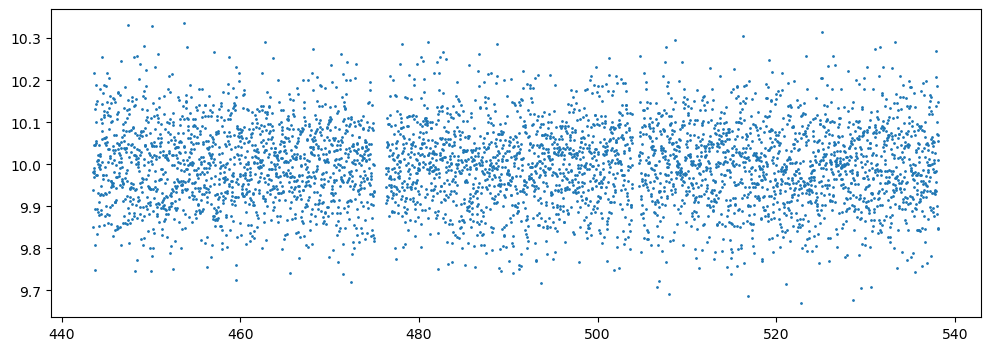

In [327]:
#plotting signal with white noise (no autocorrelation)
t = df["time"]
flux_wn = (100 + np.random.randn(len(t))) / 10
plt.figure(figsize=(12, 4))
plt.plot(t, flux_wn, "." ,markersize=2)

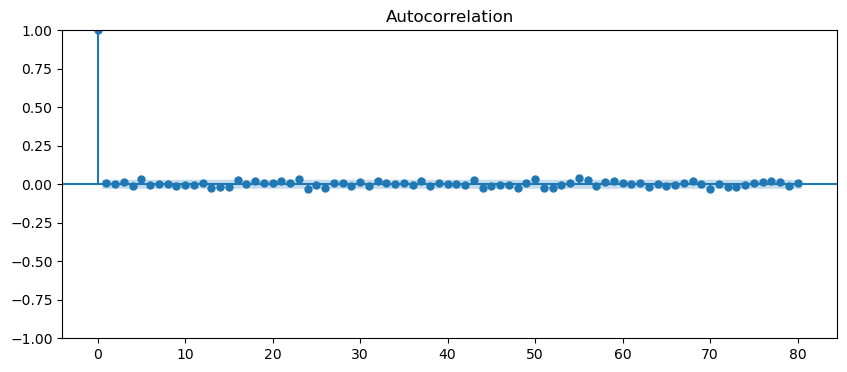

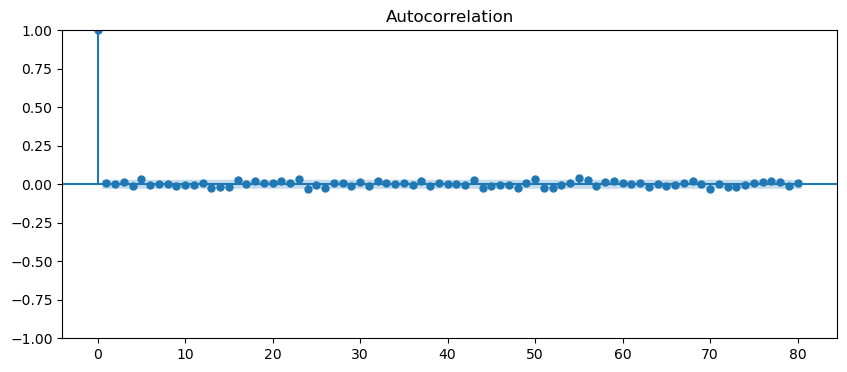

In [328]:
# For true white noise:
# lag 0 equals 1 because a series perfectly resembles itself
# almost all non-zero lags should lie near zero
# occasional bars may cross the confidence region by chance.
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(flux_wn, lags=80, ax=ax)